In [139]:
import os
from matplotlib import pyplot as plt
import numpy as np

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GlobalAveragePooling1D, Activation, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D

from sklearn.preprocessing import StandardScaler

You can estimate how fast a network prediction can be calculated by calculating the number of floating point operations performed in the network. This function is a handy tool to do it. Use it like this `print(get_flops(my_model))` where `my_model` is your KERAS neural network model.

In [140]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
import tensorflow as tf
######################################Calculate FLOPS##########################################
def get_flops(model):
    '''
    Calculate FLOPS
    Parameters
    ----------
    model : tf.keras.Model
        Model for calculating FLOPS.

    Returns
    -------
    flops.total_float_ops : int
        Calculated FLOPS for the model
    '''

    batch_size = 1

    real_model = tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] + list(model.inputs[0].shape[1:]), model.inputs[0].dtype))
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=frozen_func.graph,run_meta=run_meta, cmd='op', options=opts)
    return flops.total_float_ops

Downloading the data (1 signal data file and 5 noise data files)

In [141]:
# download data file that contains signal events
# if not os.path.exists("trimmed100_data_signal_3.6SNR_1ch_0000.npy"):
#   !gdown https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq


In [142]:
# download data file that contains noise events
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0000.npy"):
#   !gdown https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0001.npy"):
#   !gdown https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0002.npy"):
#   !gdown https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0003.npy"):
#   !gdown https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0004.npy"):
#   !gdown https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
# if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0005.npy"):
#   !gdown https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx

Load the data into memory and combine it into one array.

In [143]:
# load signal and noise data set into memory
noise = np.load("../datasets/noise-rejection/trimmed100_data_noise_3.6SNR_1ch_0000.npy")
for i in range(1,5):
  noise = np.vstack((noise,np.load(f"../datasets/noise-rejection/trimmed100_data_noise_3.6SNR_1ch_000{i}.npy")))
signal = np.load("../datasets/noise-rejection/trimmed100_data_signal_3.6SNR_1ch_0000.npy")
n_classes = 2

In [144]:
noise.shape, signal.shape

((500000, 100), (99997, 100))

In [145]:
# combine noise and signal data set
x = np.vstack((noise, signal))
print(x.shape)
# in case you want to train a CNN, you need to add an empty dimension to the array
# which you can do via x = np.expand_dims(x, axis=-1)

# define labels. As we have only two categories, we don't use one-hot encoding
# but can just use "0" for noise and "1" for signal.
y = np.ones(len(x))
y[:len(noise)] = 0

(599997, 100)


Currently, the training data first contains all noise events and then only signal events. This is not optimal, especially because Keras will pick the last X% of the data set for the validation data (which would mean we train only on noise and then validate with signal, which does not make much sense). Therefore, we randomly shuffle the dataset. Important: The x and y arrays need to be shuffled identicially as in the code below.

In [146]:
# shuffel the data
shuffle = np.arange(x.shape[0], dtype=int)
np.random.shuffle(shuffle)
x = x[shuffle]
y = y[shuffle]

# to still be able to identify the signal events you can do
smask = y == 1
# then you can get all signal events via `x[smask]`
# and all noise events via `x[~smask]`

We plot a few signal and noise events.

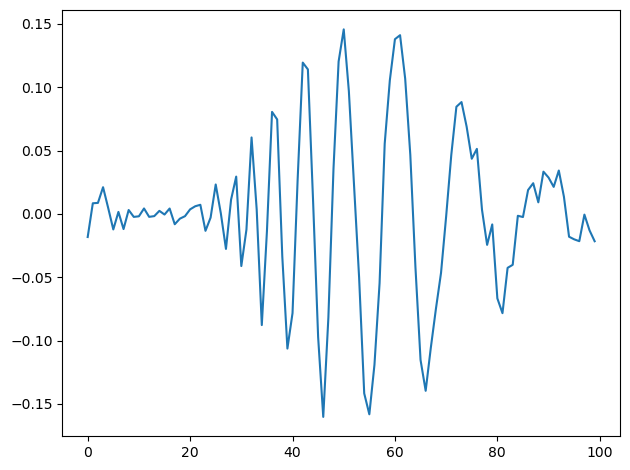

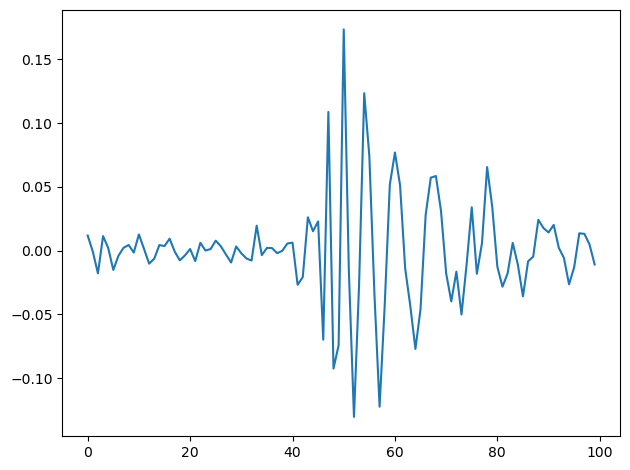

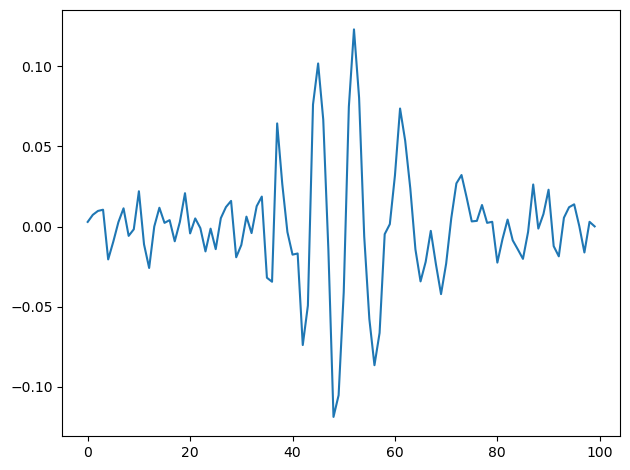

In [147]:
# plot a few signal events
for trace in x[smask][:3]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

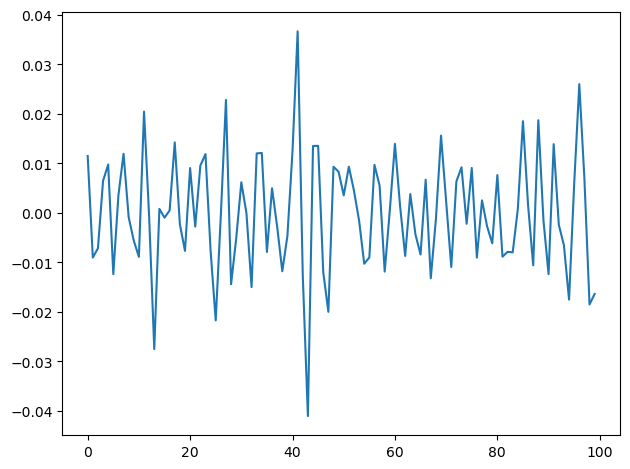

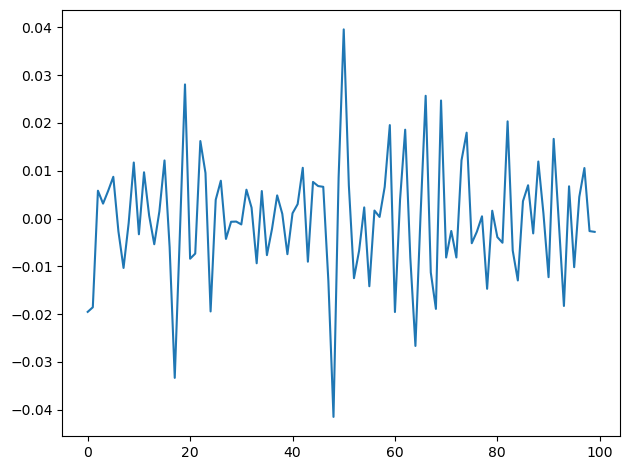

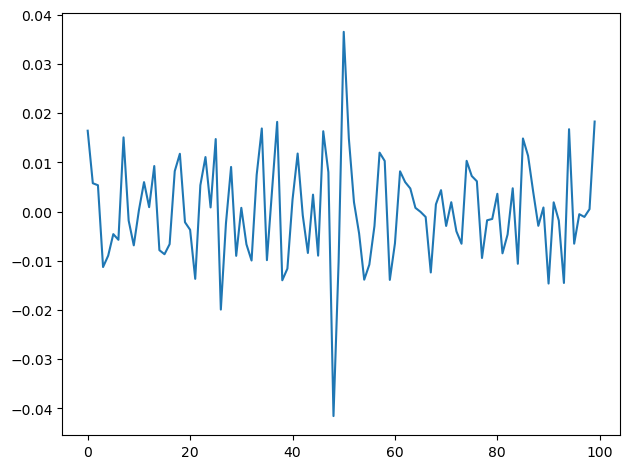

In [148]:
# plot a few signal events
for trace in x[~smask][:3]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

I do not see any clear difference between the signal and the noise events. Let us see if a neural network can do better. To that end, we first scale the data.

In [149]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

We start with a fully connected network with 2 hidden layers of 64 neurons.

In [150]:
model = keras.models.Sequential(name='noise_rejection')
model.add(keras.layers.Input(shape=(x_scaled.shape[1],)))
model.add(keras.layers.Dense(64, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(64, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation='sigmoid'))

print(model.summary())

Model: "noise_rejection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', # adam optimizer
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

In [152]:
results = model.fit(x_scaled, y,
                    epochs = 15,
                    batch_size = 32,
                    validation_split = 0.2,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
                    )

Epoch 1/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 838us/step - accuracy: 0.9874 - loss: 0.0434 - val_accuracy: 0.9917 - val_loss: 0.0285
Epoch 2/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 844us/step - accuracy: 0.9940 - loss: 0.0217 - val_accuracy: 0.9948 - val_loss: 0.0199
Epoch 3/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 804us/step - accuracy: 0.9953 - loss: 0.0176 - val_accuracy: 0.9954 - val_loss: 0.0175
Epoch 4/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 828us/step - accuracy: 0.9960 - loss: 0.0152 - val_accuracy: 0.9958 - val_loss: 0.0157
Epoch 5/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 833us/step - accuracy: 0.9965 - loss: 0.0134 - val_accuracy: 0.9960 - val_loss: 0.0160
Epoch 6/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 888us/step - accuracy: 0.9968 - loss: 0.0123 - val_accuracy: 0.9960 - val_loss: 0.0152
Epoch 7/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 812us/step - accuracy: 0.9971 - loss: 0.0113 - val_accuracy: 0.9960 - val_loss: 0.0152
Epoch 8/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 787us/s

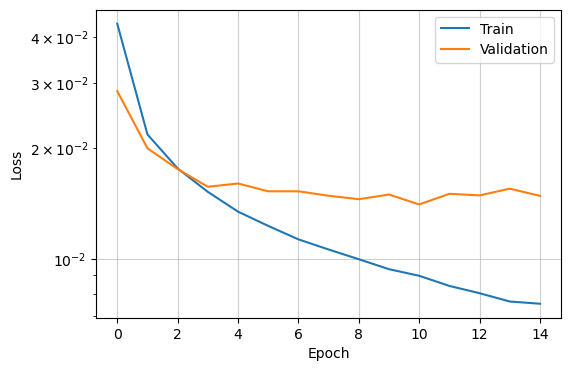

In [153]:
plt.figure(figsize=(6,4))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('Loss')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(alpha=0.6)
plt.show()

We can use the model to predict over the dataset. Then, we histogram the output for the signal and noise events.

In [154]:
y_pred = model.predict(x_scaled, batch_size=128)

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 2s 315us/step


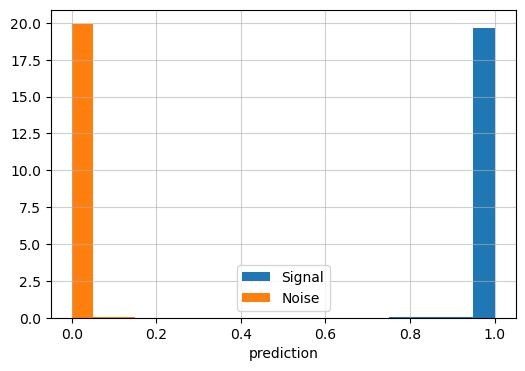

In [155]:
plt.figure(figsize=(6,4))
plt.hist(y_pred[smask], bins=20, density=True, label='Signal')
plt.hist(y_pred[~smask], bins=20, density=True, label='Noise')
plt.xlabel('prediction')
plt.grid(alpha=0.6)
plt.legend()
plt.show()

The classification is very good. Signal events have a very close to 1, while noise events are very close to 0.

We can also evaluate the model by plotting the signal efficiency vs the background rejection rate (similar to the ROC curve).

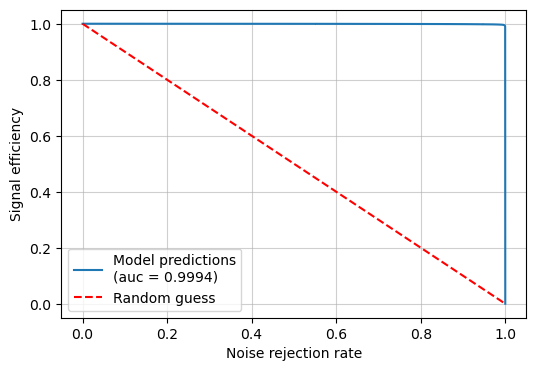

In [156]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y, y_pred)

signal_eff = tpr
noise_rejection = 1 - fpr

plt.figure(figsize=(6,4))
plt.plot(noise_rejection, signal_eff, label=f'Model predictions\n(auc = {auc(fpr,tpr):.4f})')
plt.xlabel('Noise rejection rate')
plt.ylabel('Signal efficiency')
# plt.fill_between(
#     x=[0.999, 1.0], 
#     y1=0.90, 
#     y2=1.0, 
#     color='tab:purple', 
#     alpha=0.4, 
#     label='Target region'
# )
plt.plot([0, 1], [1, 0], color='red', ls='--', label='Random guess')
plt.grid(alpha=0.6)
plt.legend()
plt.show()

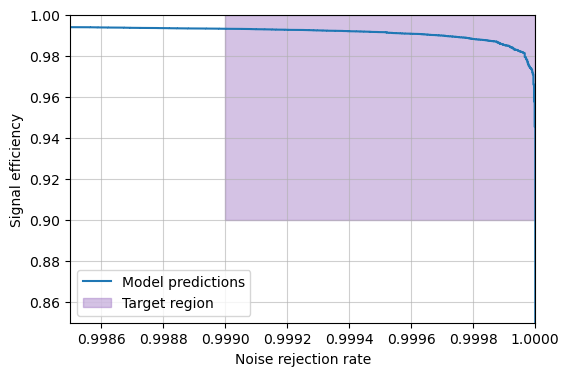

In [157]:
plt.figure(figsize=(6,4))
plt.plot(noise_rejection, signal_eff, label=f'Model predictions')
plt.xlabel('Noise rejection rate')
plt.ylabel('Signal efficiency')
plt.fill_between(
    x=[0.999, 1.0], 
    y1=0.90, 
    y2=1.0, 
    color='tab:purple', 
    alpha=0.4, 
    label='Target region'
)
plt.xlim(0.9985, 1)
plt.ylim(0.85, 1)
plt.grid(alpha=0.6)
plt.legend()
plt.show()

The curve passes through the target region (more than 99.9% of noise rejection, more than 90% of signal efficiency), so the model provides the desired performance.

Now, we can compute the number of floating operations of the network.

In [158]:
flops = get_flops(model)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================


I0000 00:00:1783272103.132758   24928 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1783272103.132848   24928 single_machine.cc:376] Starting new session



Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profile:
node name | # float_ops
MatMul                   21.12k float_ops (100.00%, 99.39%)
BiasAdd                    128 float_ops (0.61%, 0.60%)
AddV2                        1 float_ops (0.00%, 0.00%)

======================End of Report==========================


In [159]:
print(f'Number of floating operations: {flops}')

Number of floating operations: 21249


Let us see if we can keep the performance in the target region while decreasing the number of floating operations. 

We will try with a simpler model with 4 hidden layers of 8 neurons.

In [160]:
model = keras.models.Sequential(name='noise_rejection')
model.add(keras.layers.Input(shape=(x_scaled.shape[1],)))
model.add(keras.layers.Dense(8, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(8, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(8, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(8, activation='relu',), keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation='sigmoid'))

print(model.summary())

Model: "noise_rejection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 8)              │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,033 (4.04 KB)

 Trainable params: 1,033 (4.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [161]:
model.compile(
    loss='binary_crossentropy',  # mean squared error
    optimizer='adam', # adam optimizer
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

results = model.fit(x_scaled, y,
                    epochs = 15,
                    batch_size = 32,
                    validation_split = 0.2,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
                    )

Epoch 1/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 833us/step - accuracy: 0.9684 - loss: 0.1016 - val_accuracy: 0.9866 - val_loss: 0.0471
Epoch 2/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 860us/step - accuracy: 0.9879 - loss: 0.0408 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 3/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 876us/step - accuracy: 0.9900 - loss: 0.0345 - val_accuracy: 0.9902 - val_loss: 0.0346
Epoch 4/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 829us/step - accuracy: 0.9906 - loss: 0.0325 - val_accuracy: 0.9912 - val_loss: 0.0323
Epoch 5/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 807us/step - accuracy: 0.9911 - loss: 0.0314 - val_accuracy: 0.9910 - val_loss: 0.0325
Epoch 6/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 799us/step - accuracy: 0.9912 - loss: 0.0308 - val_accuracy: 0.9907 - val_loss: 0.0322
Epoch 7/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 13s 855us/step - accuracy: 0.9914 - loss: 0.0305 - val_accuracy: 0.9911 - val_loss: 0.0311
Epoch 8/15
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 12s 778us/s

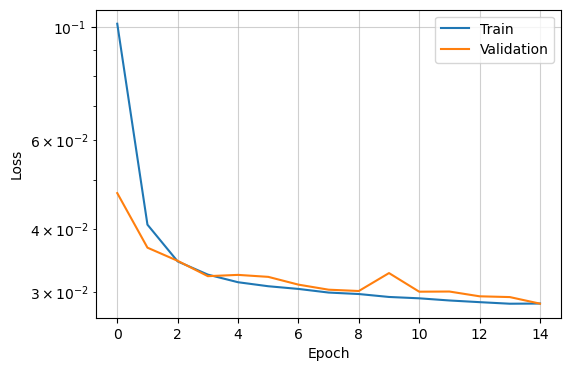

In [162]:
plt.figure(figsize=(6,4))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('Loss')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(alpha=0.6)
plt.show()

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 2s 342us/step


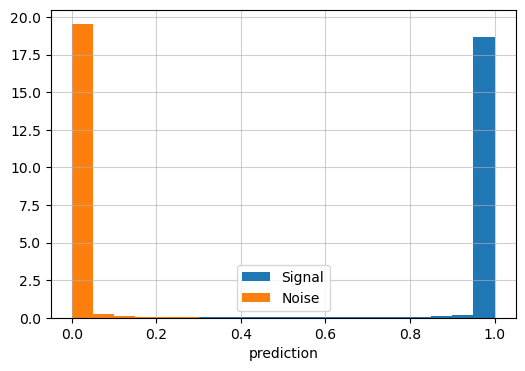

In [163]:
y_pred = model.predict(x_scaled, batch_size=128)

plt.figure(figsize=(6,4))
plt.hist(y_pred[smask], bins=20, density=True, label='Signal')
plt.hist(y_pred[~smask], bins=20, density=True, label='Noise')
plt.xlabel('prediction')
plt.grid(alpha=0.6)
plt.legend()
plt.show()

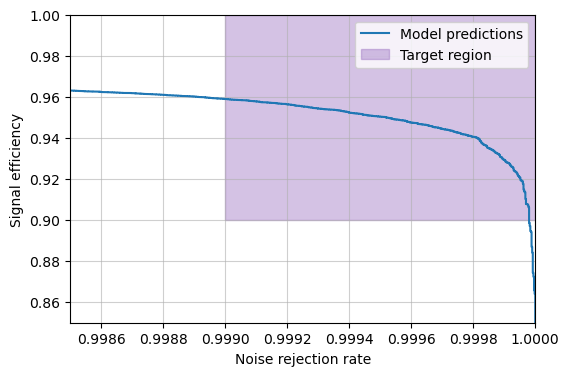

In [164]:
fpr, tpr, thresholds = roc_curve(y, y_pred)

signal_eff = tpr
noise_rejection = 1 - fpr

plt.figure(figsize=(6,4))
plt.plot(noise_rejection, signal_eff, label=f'Model predictions')
plt.xlabel('Noise rejection rate')
plt.ylabel('Signal efficiency')
plt.fill_between(
    x=[0.999, 1.0], 
    y1=0.90, 
    y2=1.0, 
    color='tab:purple', 
    alpha=0.4, 
    label='Target region'
)
plt.xlim(0.9985, 1)
plt.ylim(0.85, 1)
plt.grid(alpha=0.6)
plt.legend()
plt.show()

In [165]:
flops = get_flops(model)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================


I0000 00:00:1783272290.397178   24928 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1783272290.397260   24928 single_machine.cc:376] Starting new session



Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profile:
node name | # float_ops
MatMul                   2.00k float_ops (100.00%, 98.38%)
BiasAdd                     32 float_ops (1.62%, 1.57%)
AddV2                        1 float_ops (0.05%, 0.05%)

======================End of Report==========================


In [166]:
print(f'Number of floating operations: {flops}')

Number of floating operations: 2033


The signal efficiency vs noise rejection curve is still passing through the target area, and we managed to reduce the number of flops by a factor of 10!

We could even try a simpler model. The main number of parameters (and flops) comes from the first hidden layer, because it is connected to the 100 input neurons. Adding more layers is not that much of a problem.